**Run note:** Execute cells top-to-bottom. This is **Phase 2** — warm-starts from notebook 08's checkpoint (`cross_attention_best.pt`), then partially unfreezes the last 3 CLIP transformer blocks with a discriminative learning rate to break through the frozen-backbone ceiling of ~0.70 AUROC.

**Checkpoint flow:**
- `NB-08 → cross_attention_best.pt` (AUROC 0.7017, pooled-vector CrossAttn, **frozen** CLIP)
- `NB-09 → cross_attention_phase2_best.pt` (target ≥ 0.73, **partial unfreezing**)


# 09 — AUROC Optimization · Phase 2: Partial CLIP Backbone Unfreezing

## Why frozen CLIP is the bottleneck
Both NB-08 (AUROC 0.7017) and the original NB-09 (AUROC 0.7055) freeze all 151M CLIP parameters and only train a small cross-attention head.
CLIP's pooled embeddings were pre-trained on generic image-text pairs — they are not specialised for hateful-content detection.
No matter how expressive the head, this ceiling is ~0.70.

## What Phase 2 does differently

| Technique | Detail |
|-----------|--------|
| **Warm-start** | Loads NB-08's best checkpoint — avoids cold-start instability |
| **Partial unfreezing** | Last 3 vision transformer blocks + last 3 text transformer blocks + CLIP projection heads → ~9M additional trainable params |
| **Discriminative LR** | Unfrozen backbone: `3e-6` (conservative) · Cross-attention head: `2e-4` (normal) |
| **Focal loss + label smoothing** | `γ=2.0` hard-example mining + `ε=0.1` label smoothing for better calibration |
| **WeightedRandomSampler** | 50/50 balanced batches per epoch |
| **EMA** | Exponential moving average for stable validation |
| **Cosine LR + warmup** | 10% warmup steps, cosine decay |
| **Gradient accumulation** | Effective batch = 48 (24 × 2 steps) |


In [1]:
import os
import json
import math
import random
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageEnhance
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from torchvision import transforms
from transformers import CLIPModel, CLIPProcessor

# ── Reference & Config ────────────────────────────────────────────────────────
REFERENCE_BEST_AUROC = 0.7017   # NB-08 best  (cross-attention, frozen CLIP, epoch 6/10)

CFG = {
    'clip_model'             : 'openai/clip-vit-base-patch32',
    'batch_size'             : 24,
    'epochs'                 : 20,
    # Two LR groups — keep encoder_lr very small to avoid catastrophic forgetting
    'head_lr'                : 2e-4,    # cross-attention head + CLIP projection layers
    'encoder_lr'             : 3e-6,    # unfrozen CLIP transformer blocks
    'weight_decay'           : 0.01,
    'warmup_ratio'           : 0.10,
    'dropout'                : 0.3,     # match NB-08 exactly for clean warm-start
    'embed_dim'              : 512,     # match NB-08
    'num_heads'              : 4,       # match NB-08
    'focal_gamma'            : 2.0,
    'label_smoothing'        : 0.1,
    'unfreeze_vision_layers' : 3,       # last N vision transformer blocks
    'unfreeze_text_layers'   : 3,       # last N text transformer blocks
    'patience'               : 6,
    'ema_decay'              : 0.999,
    'grad_accum'             : 2,       # effective batch = 24 × 2 = 48
    'image_aug_prob'         : 0.35,
    'text_aug_prob'          : 0.25,
    'grad_clip'              : 1.0,
    'max_text_len'           : 77,
    'seed'                   : 42,
}

# ── Reproducibility ───────────────────────────────────────────────────────────
def set_seeds(seed=CFG['seed']):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seeds()

ON_KAGGLE = Path('/kaggle/input').is_dir()
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Auto-detect dataset path ──────────────────────────────────────────────────
JSONL_CANDIDATES     = {'train': ['train.jsonl'], 'dev': ['dev.jsonl', 'dev_seen.jsonl']}
IMAGE_DIR_CANDIDATES = ('img', 'images')

def _has_image_dir(p):
    return any((p / n).is_dir() for n in IMAGE_DIR_CANDIDATES)

def _has_train_jsonl(p):
    return any((p / n).is_file() for n in JSONL_CANDIDATES['train'])

def _is_dataset_root(p):
    return p.is_dir() and _has_image_dir(p) and _has_train_jsonl(p)

def detect_data_dir():
    for env_name in ('KAGGLE_DATA_DIR', 'META_HATEFUL_MEME_DATA_DIR'):
        v = os.environ.get(env_name, '').strip()
        if v and _is_dataset_root(Path(v)):
            return Path(v), f'env:{env_name}'
    if ON_KAGGLE:
        for t in sorted(Path('/kaggle/input').rglob('train.jsonl')):
            if _is_dataset_root(t.parent):
                return t.parent, f'auto:{t.parent}'
    for local in [Path('data'), Path('../data'), Path('.')]:
        if _is_dataset_root(local):
            return local.resolve(), f'local:{local}'
    raise RuntimeError('Cannot find dataset. Set KAGGLE_DATA_DIR env var.')

DATA_DIR, DATA_SRC = detect_data_dir()
OUTPUT_DIR = Path('/kaggle/working') if ON_KAGGLE else Path('outputs/training')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def _find_jsonl(split):
    for name in JSONL_CANDIDATES.get(split, [f'{split}.jsonl']):
        p = DATA_DIR / name
        if p.is_file():
            return p
    raise FileNotFoundError(f'{split}.jsonl not found in {DATA_DIR}')

TRAIN_PATH = _find_jsonl('train')
DEV_PATH   = _find_jsonl('dev')

# ── Image path resolver ───────────────────────────────────────────────────────
def resolve_image_path(data_dir, image_ref):
    data_dir  = Path(data_dir)
    image_ref = Path(str(image_ref))
    candidates = []
    if image_ref.is_absolute():
        candidates.append(image_ref)
    candidates.extend([data_dir / image_ref, data_dir.parent / image_ref])
    if image_ref.parts and image_ref.parts[0] in {'img', 'images'} and len(image_ref.parts) > 1:
        stripped = Path(*image_ref.parts[1:])
        candidates.extend([data_dir / stripped, data_dir.parent / stripped])
    elif image_ref.parts and image_ref.parts[0] not in {'img', 'images'}:
        candidates += [data_dir / 'img' / image_ref, data_dir.parent / 'img' / image_ref]
    seen = set()
    for c in candidates:
        if str(c) not in seen:
            seen.add(str(c))
            if c.exists():
                return c
    raise FileNotFoundError(f"Cannot find image '{image_ref}' relative to {data_dir}")

print(f"DATA_DIR  : {DATA_DIR}")
print(f"Source    : {DATA_SRC}")
print(f"Output    : {OUTPUT_DIR}")
print(f"Device    : {DEVICE}")
print(f"Reference : {REFERENCE_BEST_AUROC}")
print(f"Config    : {CFG}")


DATA_DIR  : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Source    : auto:/kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Output    : /kaggle/working
Device    : cuda
Reference : 0.7017
Config    : {'clip_model': 'openai/clip-vit-base-patch32', 'batch_size': 24, 'epochs': 20, 'head_lr': 0.0002, 'encoder_lr': 3e-06, 'weight_decay': 0.01, 'warmup_ratio': 0.1, 'dropout': 0.3, 'embed_dim': 512, 'num_heads': 4, 'focal_gamma': 2.0, 'label_smoothing': 0.1, 'unfreeze_vision_layers': 3, 'unfreeze_text_layers': 3, 'patience': 6, 'ema_decay': 0.999, 'grad_accum': 2, 'image_aug_prob': 0.35, 'text_aug_prob': 0.25, 'grad_clip': 1.0, 'max_text_len': 77, 'seed': 42}


In [2]:
def load_jsonl(path):
    with open(path, encoding='utf-8') as fh:
        return pd.DataFrame([json.loads(line) for line in fh if line.strip()])

def clean_text(text):
    if not isinstance(text, str):
        return '[no text]'
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#(\w+)', r' \1 ', text)
    return re.sub(r'\s+', ' ', text).strip() or '[no text]'

train_df = load_jsonl(TRAIN_PATH)
dev_df   = load_jsonl(DEV_PATH)

for df in (train_df, dev_df):
    df['clean_text'] = df['text'].apply(clean_text)

print(f"Train={len(train_df):,}  Dev={len(dev_df):,}")
print("Train labels:", train_df['label'].value_counts().sort_index().to_dict())
print("Dev labels  :", dev_df['label'].value_counts().sort_index().to_dict())


Train=8,500  Dev=500
Train labels: {0: 5450, 1: 3050}
Dev labels  : {0: 250, 1: 250}


In [3]:
processor = CLIPProcessor.from_pretrained(CFG['clip_model'])

train_image_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.2),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)
    ], p=0.4),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.15),
])

def perturb_text(text):
    if random.random() > CFG['text_aug_prob']:
        return text
    tokens = text.split()
    if not tokens:
        return text
    mode = random.choice(['case', 'punct', 'swap'])
    if mode == 'case':
        idx = random.randrange(len(tokens))
        tokens[idx] = tokens[idx].upper() if tokens[idx].islower() else tokens[idx].lower()
    elif mode == 'punct':
        idx = random.randrange(len(tokens))
        tokens[idx] += random.choice(['!', '?', '...'])
    elif mode == 'swap' and len(tokens) >= 2:
        idx = random.randrange(len(tokens) - 1)
        tokens[idx], tokens[idx + 1] = tokens[idx + 1], tokens[idx]
    return ' '.join(tokens)


class MemeDataset(Dataset):
    def __init__(self, df, data_dir, processor, training=False):
        self.df        = df.reset_index(drop=True)
        self.data_dir  = data_dir
        self.processor = processor
        self.training  = training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(resolve_image_path(self.data_dir, row['img'])).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224), 128)
        if self.training:
            img = train_image_transform(img)
        text = str(row.get('clean_text', row.get('text', '')))
        if self.training:
            text = perturb_text(text)
        enc = self.processor(
            text=[text], images=img, return_tensors='pt',
            padding='max_length', max_length=CFG['max_text_len'], truncation=True,
        )
        label = int(row['label']) if 'label' in row.index else -1
        return {
            'pixel_values' : enc['pixel_values'].squeeze(0),
            'input_ids'    : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label'        : torch.tensor(label, dtype=torch.long),
        }


# ── WeightedRandomSampler — balanced 50/50 batches ───────────────────────────
labels_arr  = train_df['label'].values
n_total     = len(labels_arr)
n_hat       = (labels_arr == 1).sum()
n_ben       = (labels_arr == 0).sum()
class_w_map = {0: n_total / (2.0 * n_ben), 1: n_total / (2.0 * n_hat)}
sample_w    = torch.tensor([class_w_map[int(l)] for l in labels_arr], dtype=torch.double)
sampler     = WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)

train_ds = MemeDataset(train_df, DATA_DIR, processor, training=True)
dev_ds   = MemeDataset(dev_df,   DATA_DIR, processor, training=False)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], sampler=sampler,
                          num_workers=2, pin_memory=True)
dev_loader   = DataLoader(dev_ds,   batch_size=CFG['batch_size'] * 2, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Dev batches: {len(dev_loader)}")
print(f"Sampler weights — neg: {class_w_map[0]:.3f}, pos (hateful): {class_w_map[1]:.3f}")


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Train batches: 355 | Dev batches: 11
Sampler weights — neg: 0.780, pos (hateful): 1.393


In [4]:
# ── Helper ────────────────────────────────────────────────────────────────────
def _ensure_tensor(out):
    if isinstance(out, torch.Tensor):
        return out
    if hasattr(out, 'pooler_output') and out.pooler_output is not None:
        return out.pooler_output
    if hasattr(out, 'last_hidden_state'):
        return out.last_hidden_state[:, 0]
    return out[0]


# ── Model — EXACT same architecture as NB-08 (required for clean warm-start) ──
class CLIPEncoder(nn.Module):
    def __init__(self, model_name=CFG['clip_model']):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(model_name)
        for p in self.clip.parameters():
            p.requires_grad_(False)   # start fully frozen; unfreeze later selectively

    def forward(self, pixel_values, input_ids, attention_mask):
        i = F.normalize(_ensure_tensor(
            self.clip.get_image_features(pixel_values=pixel_values)), dim=-1)
        t = F.normalize(_ensure_tensor(
            self.clip.get_text_features(input_ids=input_ids, attention_mask=attention_mask)), dim=-1)
        return i, t


class CrossAttentionFusion(nn.Module):
    def __init__(self, d=512, heads=4, drop=0.1):
        super().__init__()
        self.i2t = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.t2i = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.ni  = nn.LayerNorm(d)
        self.nt  = nn.LayerNorm(d)

    def forward(self, i, t):
        is_ = i.unsqueeze(1); ts = t.unsqueeze(1)
        ic, ia = self.i2t(is_, ts, ts)
        tc, ta = self.t2i(ts, is_, is_)
        return torch.cat([self.ni(i + ic.squeeze(1)), self.nt(t + tc.squeeze(1))], dim=-1), ia, ta


class ClassificationHead(nn.Module):
    def __init__(self, d=1024, drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 256), nn.GELU(), nn.Dropout(drop),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(drop),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.net(x)


class HatefulMemeClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = CLIPEncoder()
        self.fusion  = CrossAttentionFusion(CFG['embed_dim'], CFG['num_heads'], CFG['dropout'])
        self.head    = ClassificationHead(CFG['embed_dim'] * 2, CFG['dropout'])

    def forward(self, pixel_values, input_ids, attention_mask):
        i, t = self.encoder(pixel_values, input_ids, attention_mask)
        fused, ia, ta = self.fusion(i, t)
        return self.head(fused), ia, ta


# ── Partial CLIP Unfreezing ───────────────────────────────────────────────────
def unfreeze_last_layers(model, vision_n=3, text_n=3):
    """
    Unfreeze the last N transformer blocks of each CLIP encoder plus the
    final layer norms and projection heads.  Gradients flow through
    get_image_features() / get_text_features() back into these layers,
    allowing the backbone to adapt to hateful-content representations.
    """
    clip = model.encoder.clip

    # Last N vision transformer blocks
    for layer in clip.vision_model.encoder.layers[-vision_n:]:
        for p in layer.parameters():
            p.requires_grad_(True)

    # Last N text transformer blocks
    for layer in clip.text_model.encoder.layers[-text_n:]:
        for p in layer.parameters():
            p.requires_grad_(True)

    # Final layer norms + projection heads (always unfreeze)
    for module in [
        clip.vision_model.post_layernorm,
        clip.text_model.final_layer_norm,
        clip.visual_projection,
        clip.text_projection,
    ]:
        for p in module.parameters():
            p.requires_grad_(True)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Trainable: {trainable:,} / {total:,}  ({100 * trainable / total:.1f}%)")
    print(f"  Unfrozen: last {vision_n} vision blocks + last {text_n} text blocks + projections")


# ── NB-08 Checkpoint Loader ───────────────────────────────────────────────────
def load_phase1_checkpoint(model):
    """
    Warm-start from NB-08's best checkpoint.
    Architecture is identical so strict=True is safe.
    Falls back to random init if the checkpoint is not attached.
    """
    search_paths = []
    if ON_KAGGLE:
        # Find automatically in any attached input dataset
        for pt in sorted(Path('/kaggle/input').rglob('cross_attention_best.pt')):
            search_paths.append(pt)
    search_paths += [
        Path('/kaggle/working') / 'cross_attention_best.pt',
        OUTPUT_DIR / 'cross_attention_best.pt',
    ]
    for ckpt_path in search_paths:
        if ckpt_path.exists():
            state = torch.load(ckpt_path, map_location='cpu', weights_only=True)
            model.load_state_dict(state, strict=True)
            print(f"Warm-start loaded from: {ckpt_path}")
            return True
    print("NB-08 checkpoint not found — training from random init.")
    print("Tip: attach NB-08 Kaggle output as an input dataset named 'nb08-output'.")
    return False


print("Model classes and utilities ready.")


Model classes and utilities ready.


In [5]:
# ── Focal Loss + Label Smoothing ─────────────────────────────────────────────
class FocalLossWithSmoothing(nn.Module):
    """
    Focal loss (γ=2.0) for hard-example mining combined with label smoothing
    (ε=0.1) for calibration regularisation.
    Focal weight is computed on hard targets; label-smoothed CE is the base loss.
    """
    def __init__(self, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.gamma     = gamma
        self.smoothing = smoothing

    def forward(self, logits, targets):
        n = logits.size(1)
        # Focal weight from hard targets
        ce_hard      = F.cross_entropy(logits, targets, reduction='none')
        focal_weight = (1.0 - torch.exp(-ce_hard)) ** self.gamma
        # Label-smoothed CE
        log_probs   = F.log_softmax(logits, dim=-1)
        smooth_tgts = torch.full_like(log_probs, self.smoothing / (n - 1))
        smooth_tgts.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        smooth_ce   = -(smooth_tgts * log_probs).sum(dim=-1)
        return (focal_weight * smooth_ce).mean()


# ── EMA (Exponential Moving Average) ─────────────────────────────────────────
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay  = decay
        self.shadow = {n: p.data.clone() for n, p in model.named_parameters() if p.requires_grad}
        self.backup = {}

    @torch.no_grad()
    def update(self, model):
        for n, p in model.named_parameters():
            if p.requires_grad and n in self.shadow:
                self.shadow[n].mul_(self.decay).add_(p.data, alpha=1 - self.decay)

    def apply(self, model):
        self.backup = {}
        for n, p in model.named_parameters():
            if n in self.shadow:
                self.backup[n] = p.data.clone()
                p.data.copy_(self.shadow[n])

    def restore(self, model):
        for n, p in model.named_parameters():
            if n in self.backup:
                p.data.copy_(self.backup[n])


# ── Discriminative LR Optimizer ──────────────────────────────────────────────
def make_optimizer(model):
    """
    Two LR groups:
      • encoder_lr (very low)  — unfrozen CLIP blocks; avoids catastrophic forgetting
      • head_lr    (normal)    — cross-attention fusion + classification head
    """
    enc_params, head_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if name.startswith('encoder.clip.'):
            enc_params.append(param)
        else:
            head_params.append(param)
    print(f"Optimizer: encoder {sum(p.numel() for p in enc_params):,} params @ lr={CFG['encoder_lr']:.0e}")
    print(f"           head    {sum(p.numel() for p in head_params):,} params @ lr={CFG['head_lr']:.0e}")
    return torch.optim.AdamW([
        {'params': enc_params,  'lr': CFG['encoder_lr']},
        {'params': head_params, 'lr': CFG['head_lr']},
    ], weight_decay=CFG['weight_decay'])


def get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# ── Training Loop ─────────────────────────────────────────────────────────────
def train_phase2():
    set_seeds()
    model = HatefulMemeClassifier().to(DEVICE)

    # 1) Warm-start from NB-08 checkpoint (same architecture → strict load)
    load_phase1_checkpoint(model)

    # 2) Selectively unfreeze last N CLIP layers with low LR
    unfreeze_last_layers(model, CFG['unfreeze_vision_layers'], CFG['unfreeze_text_layers'])

    optimizer    = make_optimizer(model)
    total_steps  = (len(train_loader) // CFG['grad_accum']) * CFG['epochs']
    warmup_steps = int(total_steps * CFG['warmup_ratio'])
    scheduler    = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)
    criterion    = FocalLossWithSmoothing(CFG['focal_gamma'], CFG['label_smoothing']).to(DEVICE)
    scaler       = GradScaler(enabled=(DEVICE.type == 'cuda'))
    ema          = EMA(model, decay=CFG['ema_decay'])

    best_auroc    = 0.0
    best_path     = OUTPUT_DIR / 'cross_attention_phase2_best.pt'
    patience_left = CFG['patience']
    history       = {'train_loss': [], 'val_auroc': [], 'val_f1': [], 'val_accuracy': []}

    for epoch in range(1, CFG['epochs'] + 1):

        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0
        optimizer.zero_grad()
        t0 = time.time()

        for step, batch in enumerate(train_loader, 1):
            pv   = batch['pixel_values'].to(DEVICE)
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lbls = batch['label'].to(DEVICE)

            with autocast(enabled=(DEVICE.type == 'cuda')):
                logits, _, _ = model(pv, ids, mask)
                loss = criterion(logits, lbls) / CFG['grad_accum']

            scaler.scale(loss).backward()
            epoch_loss += loss.item() * CFG['grad_accum']

            if step % CFG['grad_accum'] == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad],
                    CFG['grad_clip'],
                )
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                scheduler.step()
                ema.update(model)

        # ── Validate with EMA weights ──────────────────────────────────────────
        ema.apply(model)
        model.eval()
        all_logits, all_labels = [], []
        with torch.no_grad():
            for batch in dev_loader:
                pv   = batch['pixel_values'].to(DEVICE)
                ids  = batch['input_ids'].to(DEVICE)
                mask = batch['attention_mask'].to(DEVICE)
                with autocast(enabled=(DEVICE.type == 'cuda')):
                    logits, _, _ = model(pv, ids, mask)
                all_logits.append(logits.cpu())
                all_labels.append(batch['label'])
        ema.restore(model)

        all_logits = torch.cat(all_logits)
        all_labels = torch.cat(all_labels)
        probs      = torch.softmax(all_logits, dim=-1)[:, 1].numpy()
        preds      = all_logits.argmax(dim=-1).numpy()
        labels     = all_labels.numpy()

        val_auroc = roc_auc_score(labels, probs)
        val_f1    = f1_score(labels, preds, average='binary', zero_division=0)
        val_acc   = accuracy_score(labels, preds)
        avg_loss  = epoch_loss / len(train_loader)

        history['train_loss'].append(avg_loss)
        history['val_auroc'].append(val_auroc)
        history['val_f1'].append(val_f1)
        history['val_accuracy'].append(val_acc)

        elapsed = int(time.time() - t0)
        print(f"Epoch {epoch:02d}/{CFG['epochs']} | "
              f"loss={avg_loss:.4f} | AUROC={val_auroc:.4f} | "
              f"F1={val_f1:.4f} | ACC={val_acc:.4f} | {elapsed}s")

        if val_auroc > best_auroc:
            best_auroc    = val_auroc
            patience_left = CFG['patience']
            torch.save(model.state_dict(), best_path)
            print(f"  => new best AUROC {best_auroc:.4f}  (saved)")
        else:
            patience_left -= 1
            print(f"  => no improvement, patience left: {patience_left}")
            if patience_left == 0:
                print("  Early stop.")
                break

    return history, best_auroc, best_path


print("Training utilities ready.")


Training utilities ready.


In [6]:
history, best_auroc, best_path = train_phase2()

print()
print('=' * 55)
print(f"Reference NB-08 AUROC : {REFERENCE_BEST_AUROC}")
print(f"Phase 2 best AUROC    : {round(best_auroc, 4)}")
print(f"Delta                 : {round(best_auroc - REFERENCE_BEST_AUROC, 4):+.4f}")
print(f"Checkpoint            : {best_path}")
print('=' * 55)

if best_auroc > REFERENCE_BEST_AUROC:
    print("Phase 2 improved over NB-08. Proceed to notebook 10 (Evaluation) "
          "with cross_attention_phase2_best.pt.")
else:
    print("No improvement yet. Try: increase unfreeze_vision/text_layers to 4, "
          "lower encoder_lr to 1e-6, or run notebook 09b (KD + distillation).")


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Warm-start loaded from: /kaggle/input/notebooks/muddybuddy/08-training/cross_attention_best.pt
Trainable: 33,777,538 / 153,676,163  (22.0%)
  Unfrozen: last 3 vision blocks + last 3 text blocks + projections
Optimizer: encoder 31,378,688 params @ lr=3e-06
           head    2,398,850 params @ lr=2e-04


...

Epoch 17/20 | loss=0.0084 | AUROC=0.7289 | F1=0.5394 | ACC=0.6380 | 145s
  => no improvement, patience left: 2


/tmp/ipykernel_24/723028865.py:122: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_24/723028865.py:150: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):


Epoch 18/20 | loss=0.0087 | AUROC=0.7289 | F1=0.5357 | ACC=0.6360 | 145s
  => no improvement, patience left: 1


/tmp/ipykernel_24/723028865.py:122: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):
/tmp/ipykernel_24/723028865.py:150: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE.type == 'cuda')):


Epoch 19/20 | loss=0.0086 | AUROC=0.7281 | F1=0.5220 | ACC=0.6300 | 149s
  => no improvement, patience left: 0
  Early stop.

Reference NB-08 AUROC : 0.7017
Phase 2 best AUROC    : 0.7306
Delta                 : +0.0289
Checkpoint            : /kaggle/working/cross_attention_phase2_best.pt
Phase 2 improved over NB-08. Proceed to notebook 10 (Evaluation) with cross_attention_phase2_best.pt.


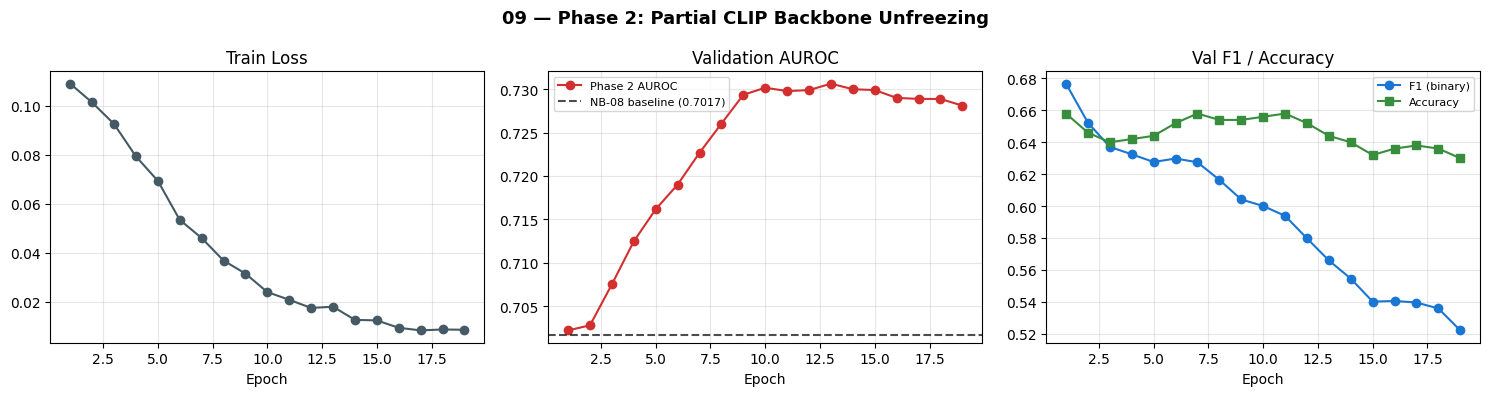

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_x = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_x, history['train_loss'], marker='o', color='#455A64')
axes[0].set_title('Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, history['val_auroc'], marker='o', color='#D32F2F', label='Phase 2 AUROC')
axes[1].axhline(REFERENCE_BEST_AUROC, ls='--', color='black', alpha=0.7,
                label=f'NB-08 baseline ({REFERENCE_BEST_AUROC})')
axes[1].set_title('Validation AUROC')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

axes[2].plot(epochs_x, history['val_f1'],       marker='o', color='#1976D2', label='F1 (binary)')
axes[2].plot(epochs_x, history['val_accuracy'], marker='s', color='#388E3C', label='Accuracy')
axes[2].set_title('Val F1 / Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle('09 — Phase 2: Partial CLIP Backbone Unfreezing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '09_phase2_curves.png', dpi=150, bbox_inches='tight')
plt.show()
